# 2D cross-well tomography


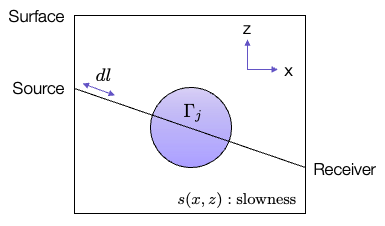

The forward simulation takes the form 

$$
t_j = \int_{\Gamma_j} s(x, y) dl
$$


where $s(x,y) = 1/v(x, y)$ is the slowness (equal to the inverse of the velocity). Note that we will work with $x$ as the first dimension and $y$ as the second dimension. 

In [64]:
import numpy as np
import matplotlib.pyplot as plt

import discretize

from simpeg import seismic

from simpeg import (
    maps,
    utils,
    survey,
)

import ipywidgets

## set up a mesh 

In [2]:
extent_x = 200 
extent_y = 400

dx = 10
dy = 10

In [3]:
nx = int(np.ceil(extent_x / dx))
ny = int(np.ceil(extent_y / dy))

hx = np.ones(nx) * dx
hy = np.ones(ny) * dy


In [4]:
mesh = discretize.TensorMesh([hx, hy])
mesh

TensorMesh: 800 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     20          0.00        200.00     10.00     10.00    1.00
   y     40          0.00        400.00     10.00     10.00    1.00

In [36]:
n_src = 25
y_src = np.linspace(dy/2, extent_y-dy/2, n_src)

source_locations = np.c_[np.zeros_like(y_src), y_src]
receiver_locations = np.c_[np.zeros_like(y_src) + mesh.nodes_x[-1], y_src]

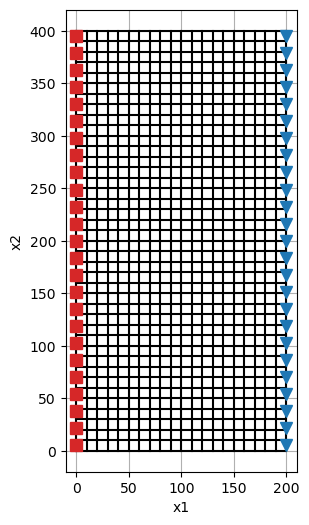

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

mesh.plot_grid(ax=ax, color="k")
ax.set_aspect(1)

ax.plot(source_locations[:, 0], source_locations[:, 1], "C3s", ms=8)
ax.plot(receiver_locations[:, 0], receiver_locations[:, 1], "C0v", ms=8)


## build model

In [38]:
v0 = 1000
v1 = 2000
v2 = 500

block_x1 = np.r_[60, 140]
block_y1 = np.r_[250, 300]

block_x2 = np.r_[60, 140]
block_y2 = np.r_[100, 150]

velocity_model = v0*np.ones(mesh.n_cells)
background_velocity = velocity_model.copy()

In [39]:
def add_block(velocity_model, block_x, block_y, value): 
    inds_block = (
        (mesh.cell_centers[:, 0] > block_x.min()) &
        (mesh.cell_centers[:, 0] < block_x.max()) &
        (mesh.cell_centers[:, 1] > block_y.min()) &
        (mesh.cell_centers[:, 1] < block_y.max()) 
    ) 

    velocity_model[inds_block] = value
    
    return velocity_model
    
velocity_model = add_block(velocity_model, block_x1, block_y1, v1) 
velocity_model = add_block(velocity_model, block_x2, block_y2, v2) 


true_slowness_model = 1/velocity_model
background_slowness_model = 1/background_velocity

In [40]:
def plot_model_survey(
    mesh, model, source_locations, receiver_locations, ax=None, 
    show_raypaths=True, vmin=None, vmax=None
):
    if ax is None: 
        fig, ax = plt.subplots(1, 1)
    
    cb = plt.colorbar(
        mesh.plot_image(model, ax=ax, pcolor_opts={"vmin":vmin, "vmax":vmax})[0], 
        ax=ax
    )
    
    cb.set_label("slowness (s/m)")
    
    ax.set_aspect(1)

    ax.plot(source_locations[:, 0], source_locations[:, 1], "ws", ms=6)
    ax.plot(receiver_locations[:, 0], receiver_locations[:, 1], "wv", ms=6)
    
    if show_raypaths is True: 
        for i in range(source_locations.shape[0]):
            for j in range(receiver_locations.shape[0]):
                ax.plot(
                    np.r_[source_locations[i, 0], receiver_locations[j, 0]],
                    np.r_[source_locations[i, 1], receiver_locations[j, 1]],
                    color="w",
                    linewidth=0.2
                )
    return ax



<Axes: xlabel='x', ylabel='y'>

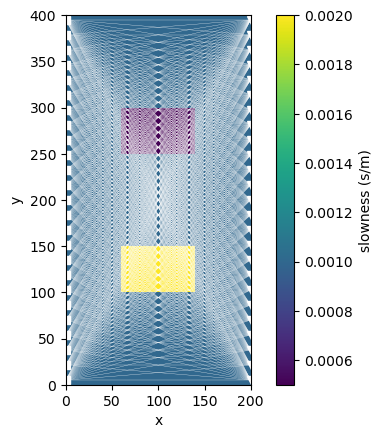

In [41]:
plot_model_survey(
    mesh, true_slowness_model, source_locations, receiver_locations,
    show_raypaths=True
)

## create a survey and simulation

In [42]:
rx = survey.BaseRx(receiver_locations)

source_list = [
    survey.BaseSrc(
        location=source_locations[i, :], receiver_list=[rx]
    )
    for i in range(y_src.size)
]

In [43]:
tomo_survey = seismic.straight_ray_tomography.Survey(source_list)

In [44]:
simulation = seismic.straight_ray_tomography.Simulation(
    mesh=mesh,
    survey=tomo_survey,
    slownessMap=maps.IdentityMap(mesh),
)

## simulate data

In [45]:
background_data = simulation.dpred(background_slowness_model)
clean_data = simulation.dpred(true_slowness_model)

In [70]:
relative_error=0.01
np.random.seed(1)

noisy_data = (
    clean_data + 
    np.random.randn(len(clean_data)) * relative_error * np.abs(clean_data)
)
background_noisy_data = (
    background_data + 
    np.random.randn(len(clean_data)) * relative_error * np.abs(background_data)
)

In [71]:
dobs = noisy_data

## plot the simulated data

In [72]:
def plot_data(dplot, ax=None): 
    if ax is None: 
        fig, ax = plt.subplots(1, 1)
    cb = plt.colorbar(ax.contourf(dplot.reshape(n_src, n_src, order="F")))
    
    CS = ax.contour(
            dplot.reshape(n_src, n_src, order="F"), 
            colors="k",
            linewidths=1,
    )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_aspect(1)

    ax.set_xlabel("RX")
    ax.set_ylabel("TX")
    cb.set_label("time (s)")

    return ax

Text(0.5, 1.0, '(b) observed data')

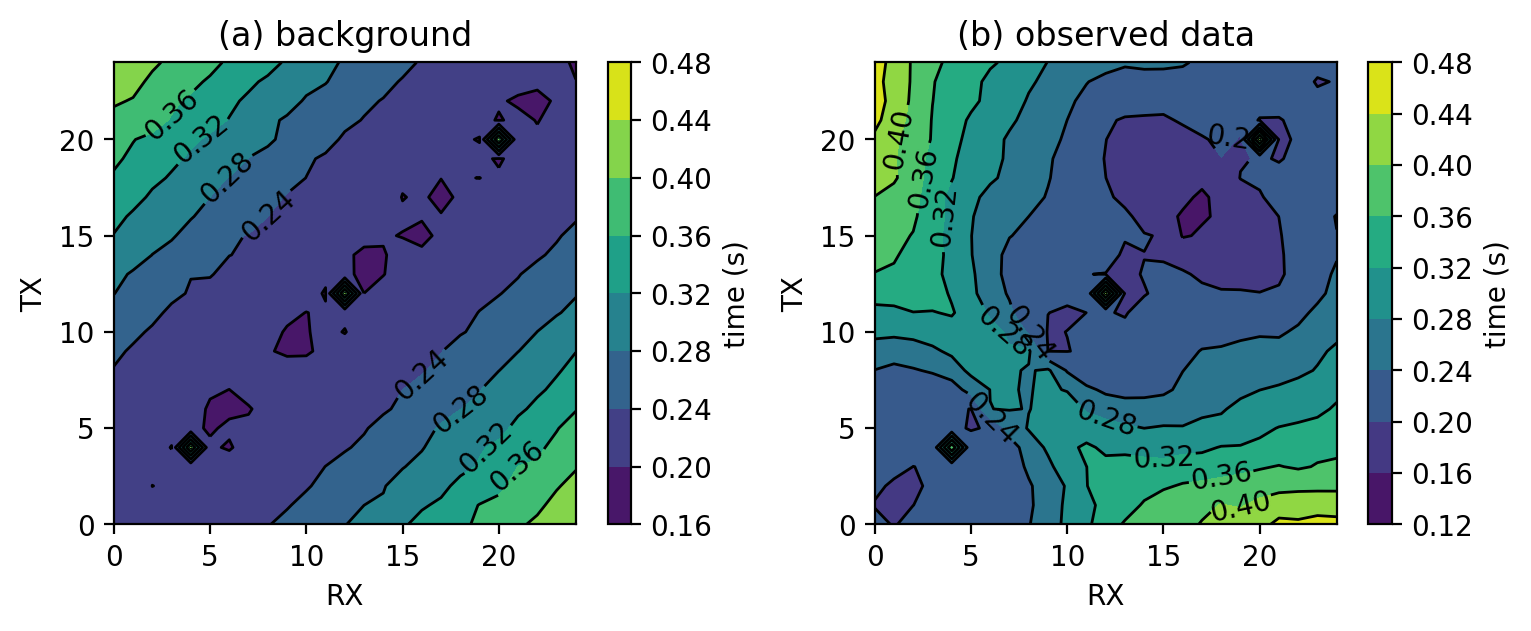

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=200)

for i, dplot in enumerate([background_noisy_data, noisy_data]): 
    plot_data(dplot, ax=ax[i])

ax[0].set_title("(a) background")
ax[1].set_title("(b) observed data")

In [74]:
G = simulation.A

In [75]:
U, singular_values, VT = np.linalg.svd(G.toarray(), full_matrices=False)

In [76]:
V = VT.T

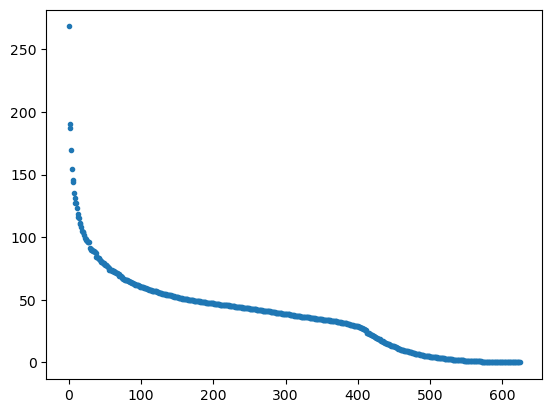

In [77]:
plt.plot(singular_values, ".")

In [78]:
def plot_svd(index=0): 
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].semilogy(l, ".")
    ax[0].semilogy(index, l[index], "C3o")
    ax[1].plot(V[:, index])

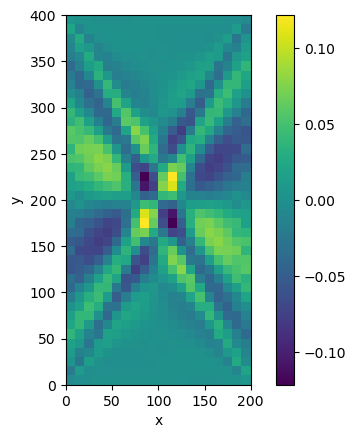

In [79]:
fig, ax = plt.subplots(1, 1)
index=10
plt.colorbar(mesh.plot_image(V[:, index], ax=ax)[0], ax=ax)

ax.set_aspect(1)

In [80]:
def get_m_at_index(index=0):
    ud = np.squeeze(U[:, index].T @ dobs)
    return ud / singular_values[index] * V[:, index]

In [81]:
def reconstruct_m_svd(n_vectors=1):
    msvd = np.zeros(mesh.n_cells)
    for i in range(n_vectors): 
        msvd = msvd + get_m_at_index(i)
    return msvd

In [82]:
msvd_all = np.zeros((mesh.n_cells, len(dobs)))
dpred_all = np.zeros((len(dobs), len(dobs)))
phi_d_all = np.zeros(len(dobs))

for i in range(len(dobs)):
    msvd_all[:, i] = reconstruct_m_svd(i+1)
    dpred_all[:, i] = G @ msvd_all[:, i]
    
    r = 1/(relative_error * np.abs(dobs)) * (dpred_all[:, i] - dobs)
    phi_d_all[i] = r.T @ r

In [83]:
def plot_svd_solution(index): 
    fig, ax = plt.subplots(2, 3, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 2]})
    
    ax[0, 0].plot(singular_values, ".")
    ax[0, 0].plot(singular_values[:index+1], "s")
    ax[0, 0].set_title("(a) singular values")
    
    for i, dplot in enumerate([dobs, dpred_all[:, index]]): 
        plot_data(dplot, ax[0, i+1])
    ax[0, 1].set_title("(b) observed data")
    ax[0, 2].set_title("(c) predicted data")
    
    
    plot_model_survey(
        mesh, get_m_at_index(index), source_locations, receiver_locations,
        show_raypaths=False, ax=ax[1, 0]
    )
    ax[1, 0].set_title(f"(d) singular vector {index}")
    
    plot_model_survey(
        mesh, true_slowness_model, source_locations, receiver_locations,
        show_raypaths=True, ax=ax[1, 1]
    )
    ax[1, 1].set_title("(e) true model")
    
    
    plot_model_survey(
        mesh, msvd_all[:, index], source_locations, receiver_locations,
        show_raypaths=False, ax=ax[1, 2]
    )
    ax[1, 2].set_title("(f) predicted model")
    
    
    
    plt.tight_layout()

In [84]:
ipywidgets.interact(
    plot_svd_solution, 
    index=ipywidgets.IntSlider(min=0, max=len(dobs)-1, value=0)
)

interactive(children=(IntSlider(value=0, description='index', max=624), Output()), _dom_classes=('widget-inter…

<function __main__.plot_svd_solution(index)>